**SARIMA BASELINE MODEL**

*This notebook was created and ran using Google Colab.




In [3]:
#Installing some extra packages.
#The session crashes after running this block, but it works properly afterwards.
!pip install -q condacolab
import condacolab
condacolab.install()
!conda install -c conda-forge pmdarima -y

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...
Channels:
 - conda-forge
Platform: linux-64
Solving environment: - \ done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - pmdarima


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.6.15  |       hbd8a1cb_0         148 KB  conda-forge
    certifi-2025.6.15          |     pyhd8ed1ab_0         152 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    cython-3.1.2               |  py311ha3e34f5_2         3.5 MB  conda-forge
    joblib-1.5.1               |     pyhd8ed1ab_0         219 KB  conda-forge
    libblas-3.9.0              |31_h59b

In [1]:
#Import basic packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

#Import models needed for ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from sklearn.metrics import mean_squared_error as mse

In [2]:
#Reading the data. The Data MUST be reuploaded at the start of every session.
energy = pd.read_csv("/content/uk_data_clean.csv")
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17424240 entries, 0 to 17424239
Data columns (total 5 columns):
 #   Column        Dtype  
---  ------        -----  
 0   datetime      object 
 1   id            object 
 2   target        float64
 3   date          object 
 4   time_seconds  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 664.7+ MB


In [3]:
#Reorder the data so it is easier to manage as a time series.
pivoted = energy.pivot(index="datetime", columns="id", values="target")

#datetime column contains strings, we must change them to a datetime object.
def dtarg(x):
  return(pd.to_datetime(x,format='%Y-%m-%d %H:%M:%S'))

pivoted.index = pivoted.index.map(dtarg)

pivoted.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18960 entries, 2012-11-01 00:00:00 to 2013-11-30 23:30:00
Columns: 919 entries, uk_MAC000010 to uk_MAC005552
dtypes: float64(919)
memory usage: 133.1 MB


<Axes: title={'center': 'Household Monthly Average Energy Consumption'}, xlabel='Month', ylabel='Average Energy Consumption (kWh)'>

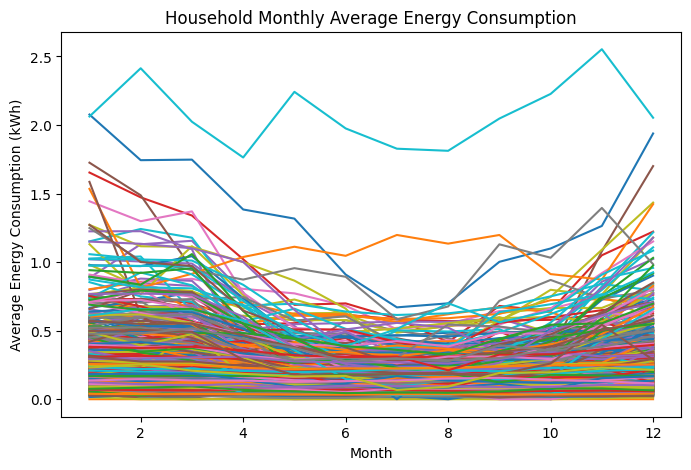

In [4]:
#The data includes 18960 different households.
#The following graph shows their monthly average energy consumption.
#We can see a yearly seasonal trend.

pivoted.groupby(pivoted.index.month).mean().plot(figsize = (8,5),
                                                 legend=False,
                                                 title = 'Household Monthly Average Energy Consumption',
                                                 xlabel = 'Month',
                                                 ylabel = 'Average Energy Consumption (kWh)')



In [5]:
#We split our data into a training and a testing set. We set apart 1 out of 13 months.
pivoted['year'] = pivoted.index.year
pivoted['month'] = pivoted.index.month

pivoted_test = pivoted[(pivoted['year'] == 2013) & (pivoted['month'] == 11)]
pivoted_train = pivoted[~((pivoted['year'] == 2013) & (pivoted['month'] == 11))]

#The data also shows daily and weekly seasonal trends.
#Standard SARIMA models may only handle one type of seasonality.
#SARIMA models using the bihourly data we have are extremely slow.
#We decide to work instead with daily average energy consumption.
#This reduces the amount of data the models with process, and removes the daily seasonality.

daily_train = pivoted_train.groupby(pivoted_train.index.date).mean()
daily_test = pivoted_test.groupby(pivoted_test.index.date).mean()



#It will also be convenient later to have the weekly averages.
weekly_train = daily_train.groupby(np.arange(len(daily_train)) // 7).mean()



#Remove the month and year columns.
daily_train = daily_train.drop(columns=['year', 'month'])
daily_test = daily_test.drop(columns=['year', 'month'])



ACF and PACF plots for House  742 which has ID uk_MAC004831


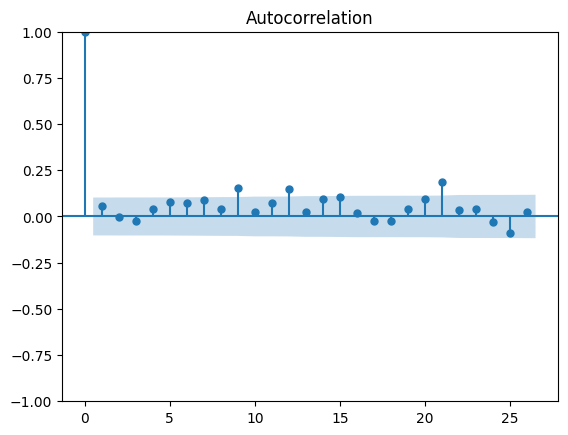

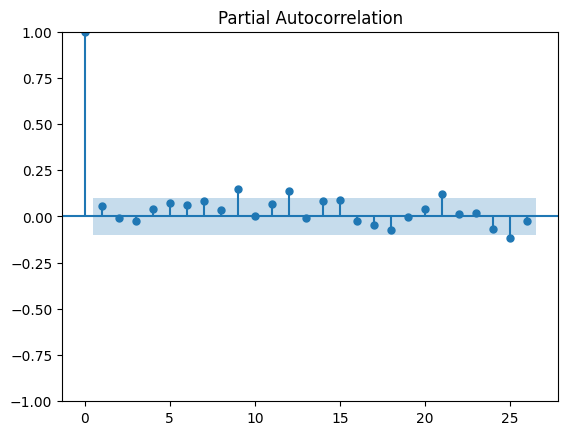

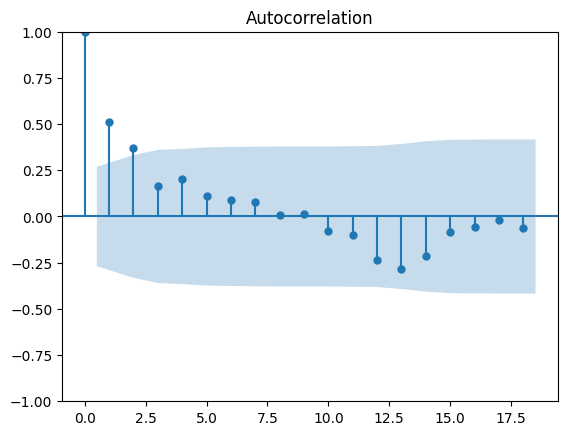

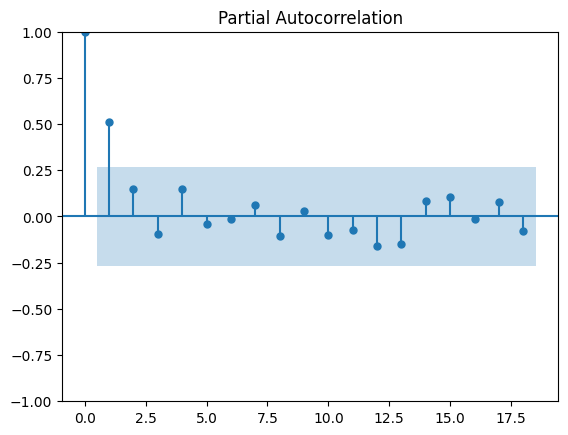

ACF and PACF plots for House  47 which has ID uk_MAC000376


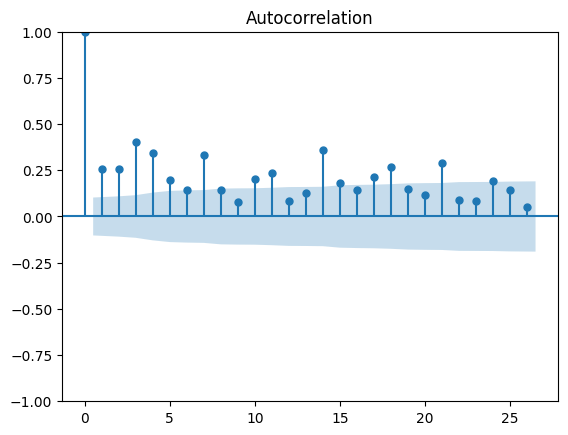

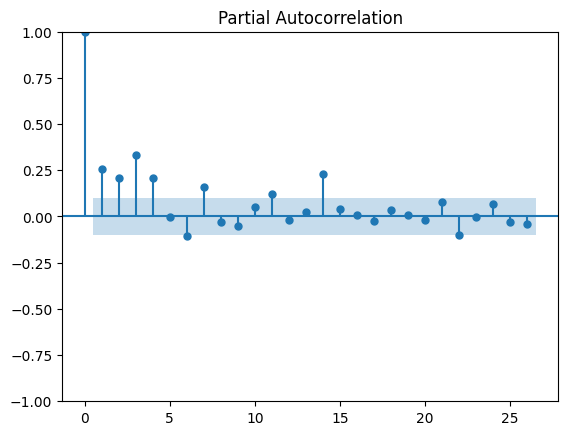

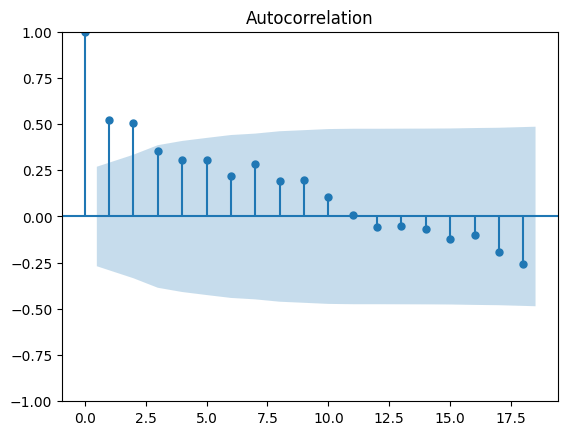

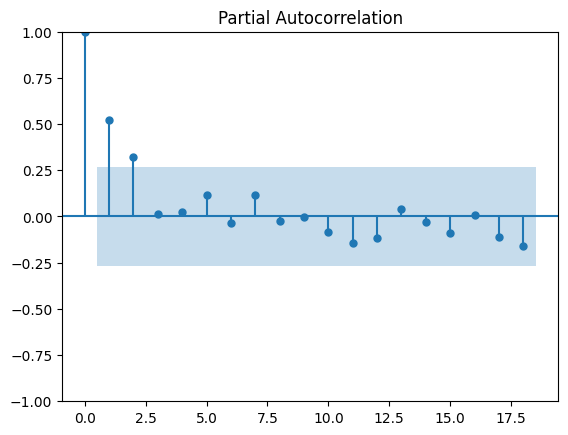

ACF and PACF plots for House  385 which has ID uk_MAC002609


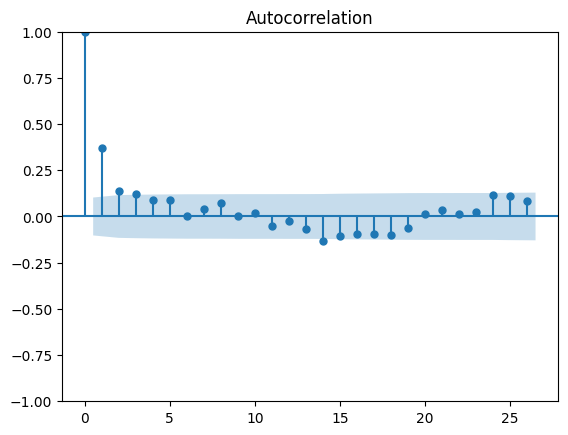

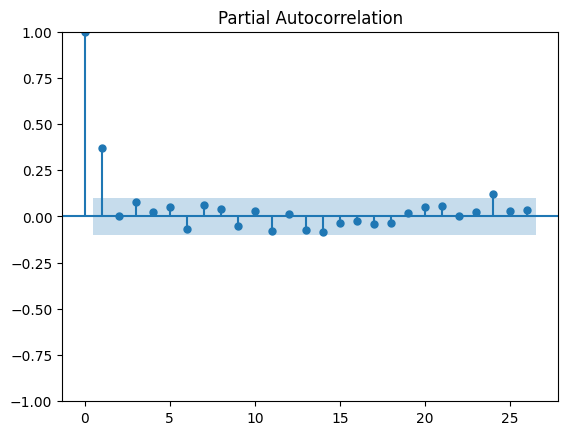

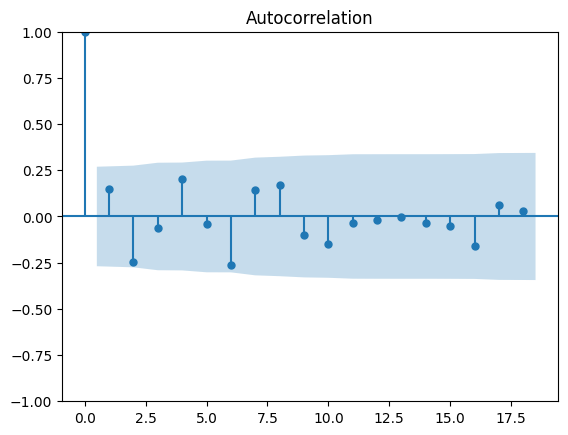

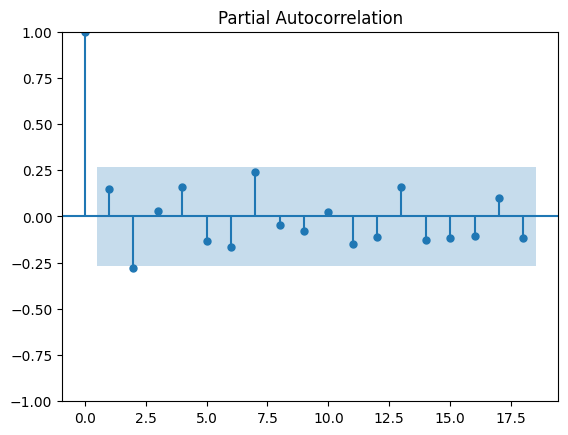

ACF and PACF plots for House  500 which has ID uk_MAC003375


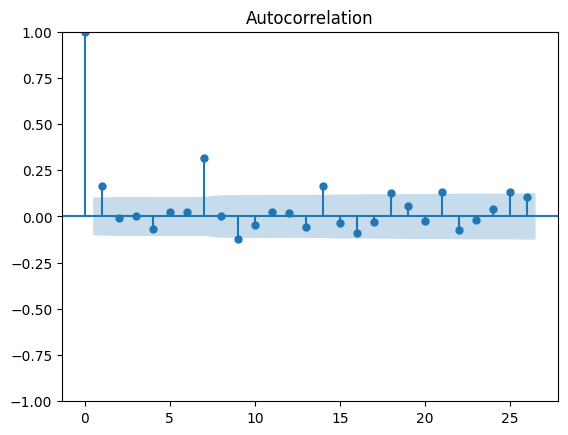

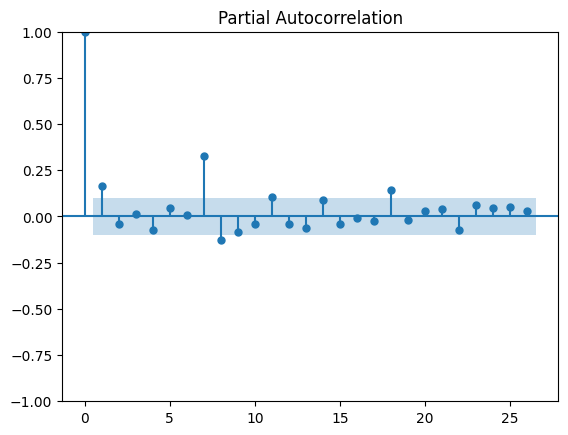

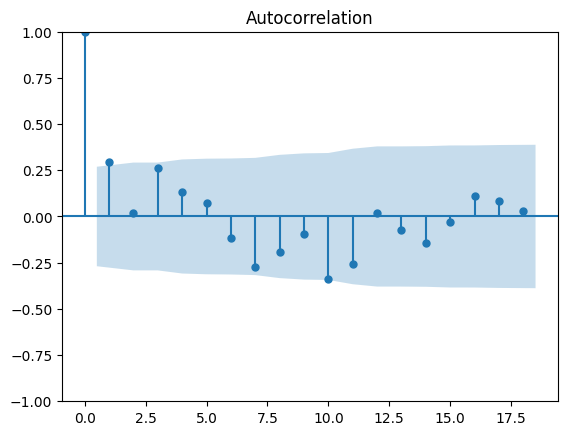

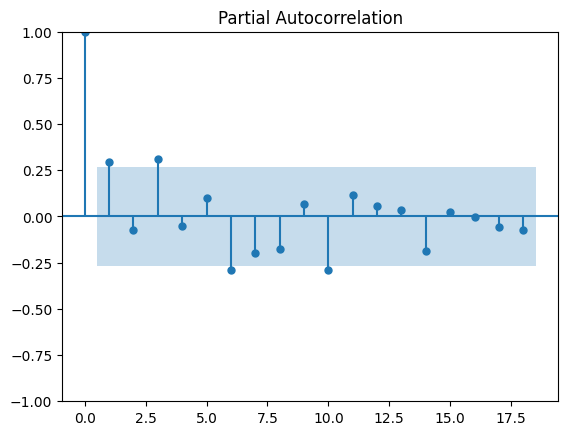

ACF and PACF plots for House  277 which has ID uk_MAC001884


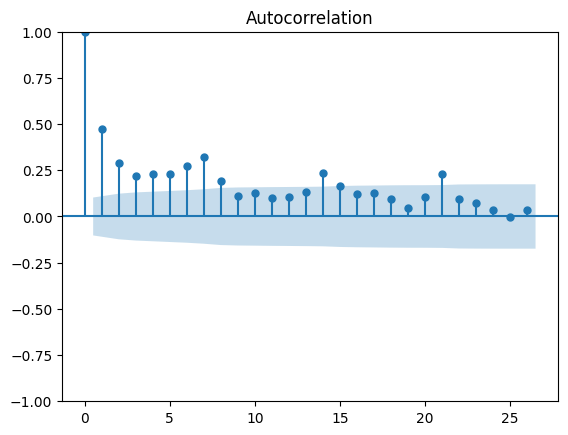

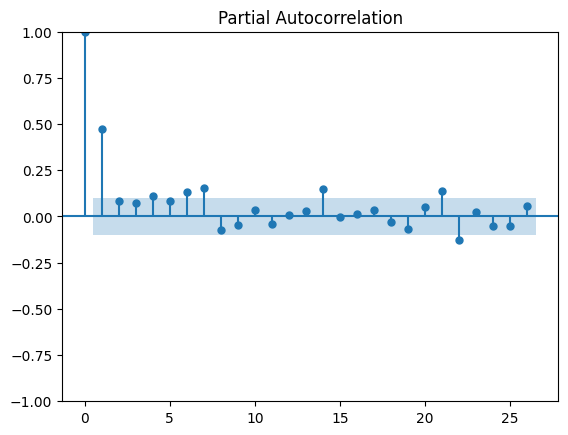

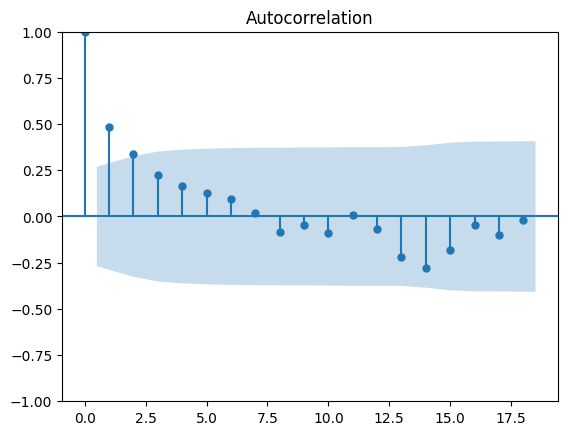

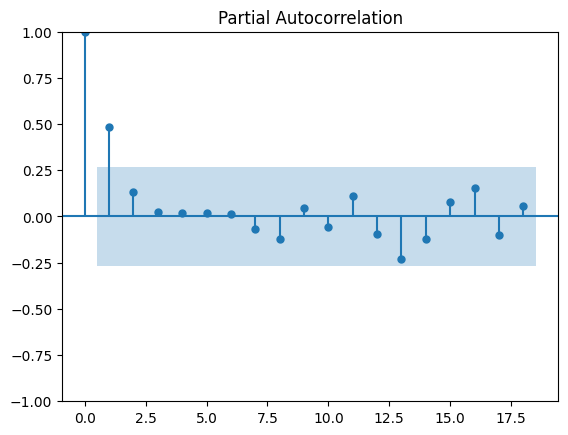

In [6]:
#We plot the acf and pacf for a few random households.
houses = np.random.randint(1, len(pivoted.columns) - 2, 5)
for i in houses:
  print('ACF and PACF plots for House ', i, 'which has ID', daily_train.columns[i])
  plot_acf(daily_train[daily_train.columns[i]])
  plot_pacf(daily_train[daily_train.columns[i]])
  plot_acf(weekly_train[weekly_train.columns[i]])
  plot_pacf(weekly_train[weekly_train.columns[i]])
  plt.show()

In [7]:
#We wish to set a SARIMA model with order (p,d,q) and seasonal order (P,D,Q,s).
#Multiple parameters were tried manually or via auto_arima.
#Here are the parameters we chose since they gave good results, with a short explanation of why they work.
#From the different ACF and PACF plots we can get some information.
#We usually see a weekly seasonal trend, so we set s=7.
#From looking at the multiple daily pacf plots, we set p=3.
#From the weekly pacf plots, we set P=2.
#From the monthly average graph earlier, approximately showing a parabola, we set D=2.
#From the ACF plots, we choose q=1 and Q=1.
#Since it seemed to work better, we also choose d=2.


#For every household, we create a SARIMA model of order (3,2,1) and seasonal order (2,2,1,7).
#We make predictions using this models and compute the average mse over all households.

daily_mse = []

for i in daily_train.columns:
  daily_arima_i = pm.ARIMA(order=(3, 2, 1), seasonal_order=(2,2,1,7) , with_intercept = False).fit(daily_train[i])
  daily_mse.append(mse(daily_test[i], daily_arima_i.predict(len(daily_test[i]))))

print('The average MSE over all households is ', np.mean(daily_mse))






Se truncaron las últimas líneas 5000 del resultado de transmisión.
/usr/local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information w

The average MSE over all households is  0.028899691363238847


/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [7]:
#For comparison, we also include a Naive model.
#The model averages the household consumption data from November of the previous year.
november_train = pivoted[(pivoted['year'] == 2012) & (pivoted['month'] == 11)]
november_mean = november_train.mean()
daily_mse = []
for i in pivoted.columns[:-2]:
  daily_mse.append(mse(daily_train[i], [november_mean[i] for j in range(len(daily_train[i]))]))

print('The average MSE over all households is ', np.mean(daily_mse))




The average MSE over all households is  0.017177689829088016


In [ ]:
#A graph showing the forecast for house i.
#i = np.random.randint(0, len(daily_train.columns))
#arima = pm.ARIMA(order=(3, 2, 1), seasonal_order=(2,2,1,7) , with_intercept = False).fit(daily_train[i])

#plt.figure(figsize=(16,6))

#plt.plot(daily_train.index,
#            daily_train[i],
#            'b',
#            label="Training Set")

#plt.plot(daily20_train.index,
#            arima.fittedvalues,
#            c='green',
#            label="Fit on Training")

#plt.plot(daily_test[i].index,
#            daily_test[i],
#            'r',
#            label="Test Set")


#plt.plot(daily_test.index,
#            arima.predict(len(daily_test)),
#            'r', linestyle='dotted',
#            label="Forecast")

#plt.legend(fontsize=14, loc=2)


#plt.xlabel("Date", fontsize=16)
#plt.ylabel("Average Household Consumption", fontsize=16)


#plt.show()